# MISION: Abrir el Motor

**Objetivo:** Cargar los datos crudos de la NASA C-MAPSS (Turbofan Engine Degradation) y fabricar la variable objetivo: **Vida Util Restante (RUL)**.

---

### Contexto

El dataset C-MAPSS (Commercial Modular Aero-Propulsion System Simulation) contiene datos de **100 motores de avion** que operan hasta fallar. Cada motor tiene entre 128 y 362 ciclos de operacion, con lecturas de 21 sensores fisicos en cada ciclo.

**Por que importa:** En aviacion, un motor que falla sin aviso = catastrofe. Predecir cuantos ciclos le quedan a cada motor permite planificar mantenimiento preventivo, ahorrando millones y salvando vidas.

**Sensores fisicos del motor:**
| Sensor | Simbolo | Medida |
|--------|---------|--------|
| sensor_2 | T24 | Temperatura total en LPC outlet |
| sensor_3 | T30 | Temperatura total en HPC outlet |
| sensor_4 | T50 | Temperatura total en LPT outlet |
| sensor_7 | P30 | Presion total en HPC outlet |
| sensor_8 | Nf | Velocidad del fan fisico |
| sensor_9 | Nc | Velocidad del core fisico |
| sensor_11 | Ps30 | Presion estatica en HPC outlet |
| sensor_12 | phi | Ratio de flujo de combustible |
| sensor_13 | NRf | Velocidad del fan corregida |
| sensor_14 | NRc | Velocidad del core corregida |
| sensor_15 | BPR | Bypass ratio |
| sensor_17 | W31 | Bleed HPT coolant |
| sensor_20 | BPR_2 | Bypass ratio secundario |
| sensor_21 | W32 | Bleed LPT coolant |

**Regla de oro:** Sin target no hay modelo. Primero fabricamos el RUL.

## 1. Imports y Configuracion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo
plt.style.use('seaborn-v0_8-whitegrid')
HEALTHY = '#2ecc71'
DEGRADED = '#f39c12'
CRITICAL = '#e74c3c'

# Rutas
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
data_dir = os.path.join(project_root, "data", "cmapss")
processed_dir = os.path.join(data_dir, "processed")
os.makedirs(processed_dir, exist_ok=True)

print(f"Proyecto: {project_root}")
print(f"Datos: {data_dir}")

Proyecto: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos
Datos: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/cmapss


## 2. Carga de Datos

El archivo `train_FD001.txt` no tiene cabeceras. Son 26 columnas separadas por espacios:
- Columnas 1-2: ID del motor y ciclo actual
- Columnas 3-5: Condiciones operativas (operational settings)
- Columnas 6-26: Lecturas de 21 sensores fisicos

In [2]:
# Nombres de columnas (no vienen en el archivo)
columns = ['unit', 'time_cycles',
           'op1', 'op2', 'op3'] + \
          [f'sensor_{i}' for i in range(1, 22)]

df_train = pd.read_csv(os.path.join(data_dir, 'train_FD001.txt'),
                        sep=r'\s+', header=None, names=columns)

print(f"Dimensiones: {df_train.shape[0]:,} filas x {df_train.shape[1]} columnas")
print(f"Motores: {df_train['unit'].nunique()}")
print(f"Columnas: {list(df_train.columns)}")

Dimensiones: 20,631 filas x 26 columnas
Motores: 100
Columnas: ['unit', 'time_cycles', 'op1', 'op2', 'op3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit         20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   op1          20631 non-null  float64
 3   op2          20631 non-null  float64
 4   op3          20631 non-null  float64
 5   sensor_1     20631 non-null  float64
 6   sensor_2     20631 non-null  float64
 7   sensor_3     20631 non-null  float64
 8   sensor_4     20631 non-null  float64
 9   sensor_5     20631 non-null  float64
 10  sensor_6     20631 non-null  float64
 11  sensor_7     20631 non-null  float64
 12  sensor_8     20631 non-null  float64
 13  sensor_9     20631 non-null  float64
 14  sensor_10    20631 non-null  float64
 15  sensor_11    20631 non-null  float64
 16  sensor_12    20631 non-null  float64
 17  sensor_13    20631 non-null  float64
 18  sensor_14    20631 non-null  float64
 19  sens

In [4]:
df_train.describe().round(2)

,unit,time_cycles,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00,20631.00,20631.00,20631.00,...,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00
mean,51.51,108.81,-0.00,0.0,100.0,518.67,642.68,1590.52,1408.93,14.62,...,521.41,2388.10,8143.75,8.44,0.03,393.21,2388.0,100.0,38.82,23.29
std,29.23,68.88,0.00,0.0,0.0,0.00,0.50,6.13,9.00,0.00,...,0.74,0.07,19.08,0.04,0.00,1.55,0.0,0.0,0.18,0.11
min,1.00,1.00,-0.01,-0.0,100.0,518.67,641.21,1571.04,1382.25,14.62,...,518.69,2387.88,8099.94,8.32,0.03,388.00,2388.0,100.0,38.14,22.89
25%,26.00,52.00,-0.00,-0.0,100.0,518.67,642.33,1586.26,1402.36,14.62,...,520.96,2388.04,8133.24,8.41,0.03,392.00,2388.0,100.0,38.70,23.22
50%,52.00,104.00,0.00,0.0,100.0,518.67,642.64,1590.10,1408.04,14.62,...,521.48,2388.09,8140.54,8.44,0.03,393.00,2388.0,100.0,38.83,23.30
75%,77.00,156.00,0.00,0.0,100.0,518.67,643.00,1594.38,1414.55,14.62,...,521.95,2388.14,8148.31,8.47,0.03,394.00,2388.0,100.0,38.95,23.37
max,100.00,362.00,0.01,0.0,100.0,518.67,644.53,1616.91,1441.49,14.62,...,523.38,2388.56,8293.72,8.58,0.03,400.00,2388.0,100.0,39.43,23.62


In [5]:
df_train.head(10)

,unit,time_cycles,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


## 3. Exploracion Inicial

Cada motor tiene un numero diferente de ciclos de vida. El motor que dura mas tiene ~362 ciclos, el que menos ~128.

Ciclos por motor:
  Minimo:  128
  Maximo:  362
  Media:   206.3
  Mediana: 199.0


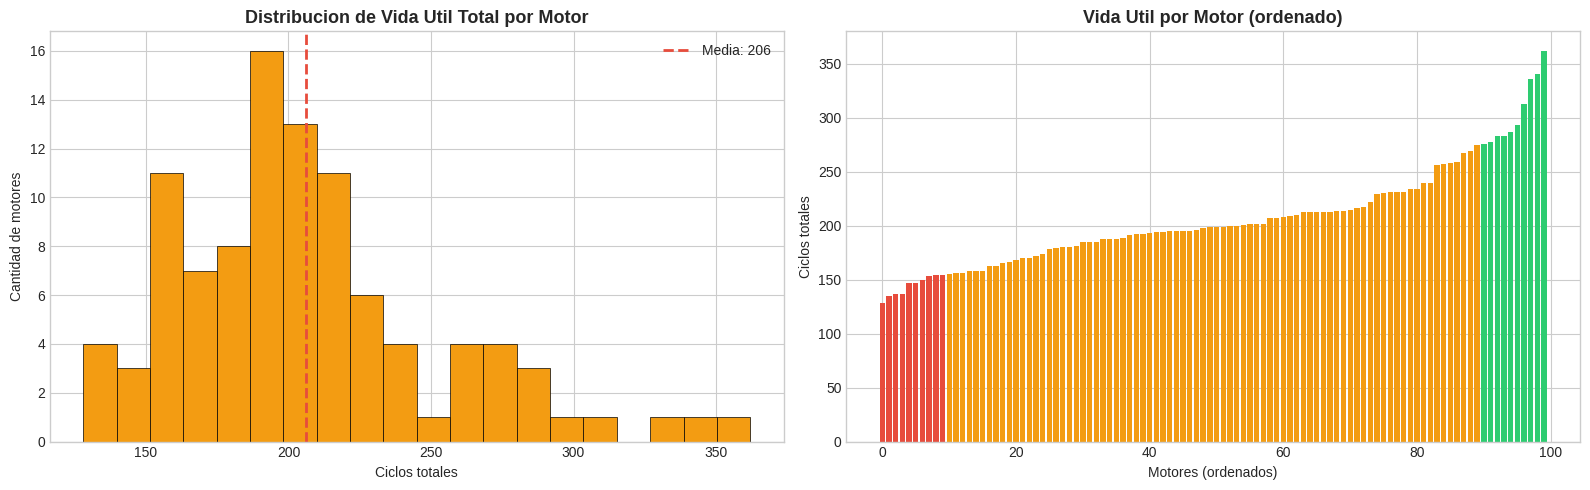

In [6]:
# Ciclos de vida por motor
cycles_per_unit = df_train.groupby('unit')['time_cycles'].max()

print(f"Ciclos por motor:")
print(f"  Minimo:  {cycles_per_unit.min()}")
print(f"  Maximo:  {cycles_per_unit.max()}")
print(f"  Media:   {cycles_per_unit.mean():.1f}")
print(f"  Mediana: {cycles_per_unit.median():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de vida util total
ax = axes[0]
ax.hist(cycles_per_unit.values, bins=20, color=DEGRADED, edgecolor='black', linewidth=0.5)
ax.axvline(cycles_per_unit.mean(), color=CRITICAL, linestyle='--', linewidth=2, label=f'Media: {cycles_per_unit.mean():.0f}')
ax.set_title('Distribucion de Vida Util Total por Motor', fontsize=13, fontweight='bold')
ax.set_xlabel('Ciclos totales')
ax.set_ylabel('Cantidad de motores')
ax.legend()

# Top 10 motores mas longevos vs mas cortos
ax = axes[1]
sorted_cycles = cycles_per_unit.sort_values()
colors = [CRITICAL]*10 + [DEGRADED]*(len(sorted_cycles)-20) + [HEALTHY]*10
ax.bar(range(len(sorted_cycles)), sorted_cycles.values, color=colors, edgecolor='none')
ax.set_title('Vida Util por Motor (ordenado)', fontsize=13, fontweight='bold')
ax.set_xlabel('Motores (ordenados)')
ax.set_ylabel('Ciclos totales')

plt.tight_layout()
plt.show()

## 4. Ingenieria del Target: RUL (Remaining Useful Life)

El RUL no viene en el dataset — hay que **calcularlo**.

**Logica:**
- Para cada motor, el ultimo ciclo registrado = momento del fallo (RUL = 0)
- RUL en cualquier ciclo = ciclo_maximo - ciclo_actual
- El motor 1 tiene 192 ciclos: en el ciclo 1, RUL=191. En el ciclo 192, RUL=0.

In [7]:
# Calcular ciclo maximo por motor
max_cycles = df_train.groupby('unit')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit', 'max_cycle']

# Merge para tener max_cycle en cada fila
df_train = df_train.merge(max_cycles, on='unit', how='left')

# Calcular RUL
df_train['RUL'] = df_train['max_cycle'] - df_train['time_cycles']

# Verificar: ultimo ciclo de cada motor debe tener RUL = 0
last_cycles = df_train.groupby('unit')['RUL'].min()
assert (last_cycles == 0).all(), "ERROR: Algun motor no tiene RUL=0 en su ultimo ciclo"
print("Verificacion OK: Todos los motores tienen RUL=0 en su ultimo ciclo")

# Mostrar ejemplo
df_train[df_train['unit'] == 1][['unit', 'time_cycles', 'max_cycle', 'RUL']].head(10)

Verificacion OK: Todos los motores tienen RUL=0 en su ultimo ciclo


,unit,time_cycles,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


## 5. Piecewise Linear RUL (Cap en 130)

**Problema con RUL lineal puro:** Un motor en el ciclo 1 con RUL=300 y otro con RUL=200 no son tan diferentes — ambos estan "sanos". La degradacion real solo es detectable en las ultimas etapas.

**Solucion:** Truncar el RUL a un maximo de 130 ciclos. Esto se llama **Piecewise Linear Degradation Model**:
- Si RUL > 130: se fija en 130 (el motor esta "sano", no nos importa cuanto exactamente)
- Si RUL <= 130: valor real (aqui empieza la degradacion detectable)

Esta decision esta respaldada por la literatura de NASA C-MAPSS y es el estandar en la comunidad.

In [8]:
RUL_CAP = 130

df_train['RUL_raw'] = df_train['RUL'].copy()
df_train['RUL'] = df_train['RUL'].clip(upper=RUL_CAP)

print(f"RUL antes del cap: min={df_train['RUL_raw'].min()}, max={df_train['RUL_raw'].max()}")
print(f"RUL despues del cap: min={df_train['RUL'].min()}, max={df_train['RUL'].max()}")
print(f"\nFilas con RUL truncado: {(df_train['RUL_raw'] > RUL_CAP).sum():,} "
      f"({(df_train['RUL_raw'] > RUL_CAP).mean()*100:.1f}%)")

RUL antes del cap: min=0, max=361
RUL despues del cap: min=0, max=130

Filas con RUL truncado: 7,534 (36.5%)


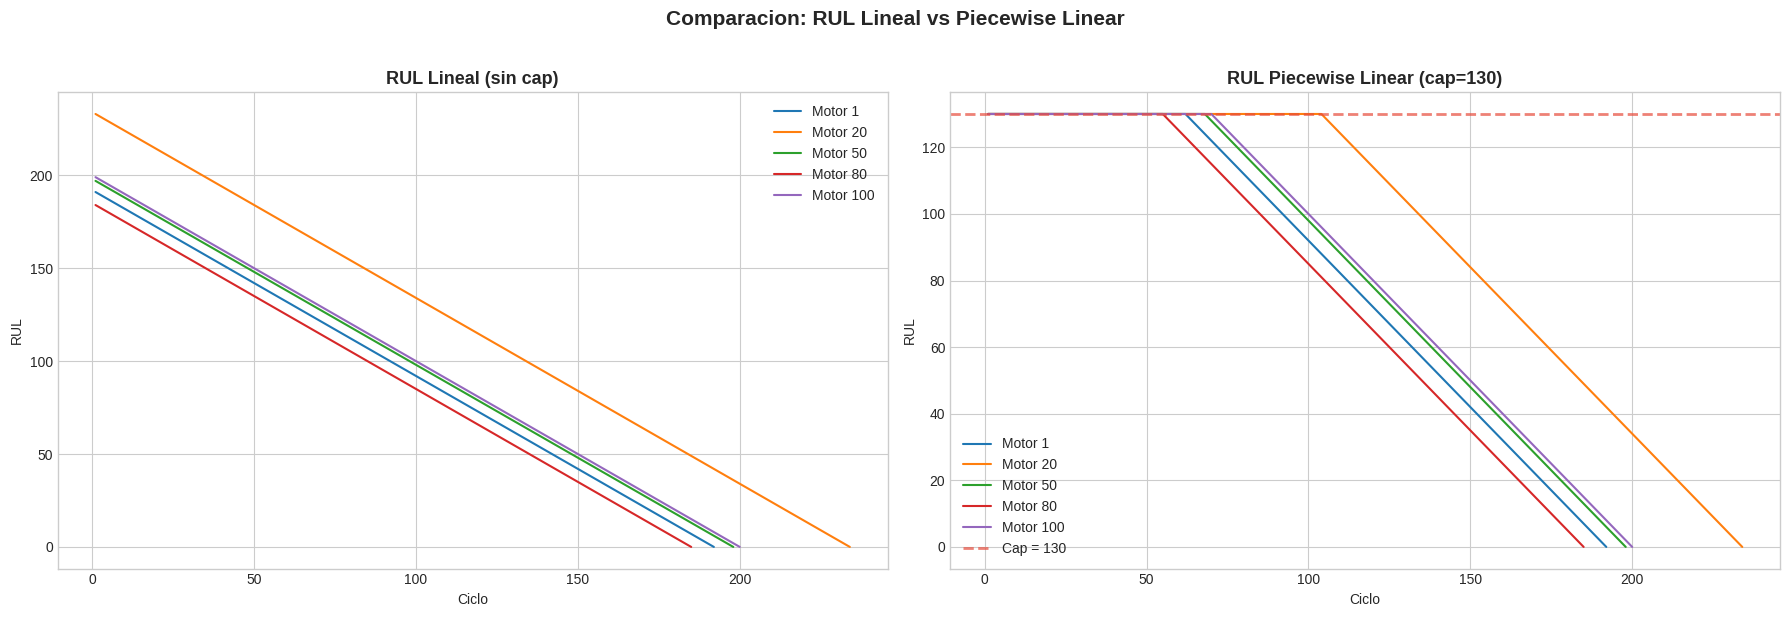

La linea plana en 130 significa: 'el motor esta sano, no importa el valor exacto'.
La pendiente descendente es donde el modelo debe ser preciso.


In [9]:
# Visualizar: RUL vs time_cycles para 5 motores de ejemplo
sample_units = [1, 20, 50, 80, 100]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# RUL raw (sin cap)
ax = axes[0]
for unit in sample_units:
    unit_data = df_train[df_train['unit'] == unit]
    ax.plot(unit_data['time_cycles'], unit_data['RUL_raw'], label=f'Motor {unit}', linewidth=1.5)
ax.set_title('RUL Lineal (sin cap)', fontsize=13, fontweight='bold')
ax.set_xlabel('Ciclo')
ax.set_ylabel('RUL')
ax.legend()

# RUL con cap (piecewise linear)
ax = axes[1]
for unit in sample_units:
    unit_data = df_train[df_train['unit'] == unit]
    ax.plot(unit_data['time_cycles'], unit_data['RUL'], label=f'Motor {unit}', linewidth=1.5)
ax.axhline(y=RUL_CAP, color=CRITICAL, linestyle='--', linewidth=2, alpha=0.7, label=f'Cap = {RUL_CAP}')
ax.set_title('RUL Piecewise Linear (cap=130)', fontsize=13, fontweight='bold')
ax.set_xlabel('Ciclo')
ax.set_ylabel('RUL')
ax.legend()

plt.suptitle('Comparacion: RUL Lineal vs Piecewise Linear', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("La linea plana en 130 significa: 'el motor esta sano, no importa el valor exacto'.")
print("La pendiente descendente es donde el modelo debe ser preciso.")

## 6. Verificacion del RUL

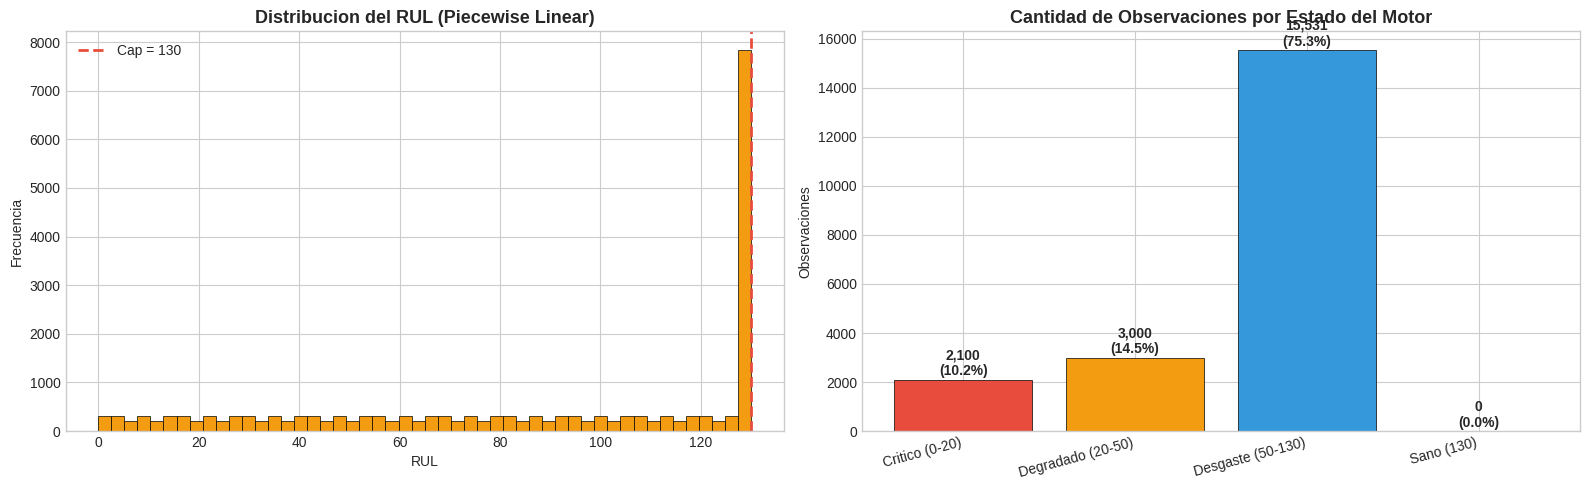

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribucion del RUL
ax = axes[0]
ax.hist(df_train['RUL'], bins=50, color=DEGRADED, edgecolor='black', linewidth=0.5)
ax.axvline(x=RUL_CAP, color=CRITICAL, linestyle='--', linewidth=2, label=f'Cap = {RUL_CAP}')
ax.set_title('Distribucion del RUL (Piecewise Linear)', fontsize=13, fontweight='bold')
ax.set_xlabel('RUL')
ax.set_ylabel('Frecuencia')
ax.legend()

# RUL por bins
ax = axes[1]
bins = [0, 20, 50, 130, 131]
labels = ['Critico (0-20)', 'Degradado (20-50)', 'Desgaste (50-130)', 'Sano (130)']
df_train['RUL_bin'] = pd.cut(df_train['RUL'], bins=bins, labels=labels, right=True, include_lowest=True)
rul_counts = df_train['RUL_bin'].value_counts().reindex(labels)
colors_bins = [CRITICAL, DEGRADED, '#3498db', HEALTHY]
ax.bar(range(len(rul_counts)), rul_counts.values, color=colors_bins, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(rul_counts)))
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_title('Cantidad de Observaciones por Estado del Motor', fontsize=13, fontweight='bold')
ax.set_ylabel('Observaciones')

for i, (count, total) in enumerate(zip(rul_counts.values, [rul_counts.sum()]*len(rul_counts))):
    ax.text(i, count + 50, f'{count:,}\n({count/total*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
# DataFrame final
print(f"Shape final: {df_train.shape}")
print(f"\nPrimeras filas con RUL:")
df_train[['unit', 'time_cycles', 'op1', 'op2', 'op3', 
          'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'RUL']].head(10)

Shape final: (20631, 30)

Primeras filas con RUL:


,unit,time_cycles,op1,op2,op3,sensor_2,sensor_3,sensor_4,sensor_7,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,130
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,130
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,130
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,130
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,130
5,1,6,-0.0043,-0.0001,100.0,642.10,1584.47,1398.37,554.67,130
6,1,7,0.0010,0.0001,100.0,642.48,1592.32,1397.77,554.34,130
7,1,8,-0.0034,0.0003,100.0,642.56,1582.96,1400.97,553.85,130
8,1,9,0.0008,0.0001,100.0,642.12,1590.98,1394.80,553.69,130
9,1,10,-0.0033,0.0001,100.0,641.71,1591.24,1400.46,553.59,130


## 7. Guardar Datos Procesados

In [12]:
# Eliminar columnas auxiliares
df_train.drop(columns=['max_cycle', 'RUL_raw', 'RUL_bin'], inplace=True)

# Guardar
output_path = os.path.join(processed_dir, 'train_FD001_with_rul.parquet')
df_train.to_parquet(output_path, index=False)

print(f"Guardado: {output_path}")
print(f"Shape: {df_train.shape}")
print(f"Columnas: {list(df_train.columns)}")
print(f"Tamano: {os.path.getsize(output_path) / 1024:.1f} KB")

Guardado: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/cmapss/processed/train_FD001_with_rul.parquet
Shape: (20631, 27)
Columnas: ['unit', 'time_cycles', 'op1', 'op2', 'op3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'RUL']
Tamano: 517.5 KB


## Resumen

1. **Datos cargados:** 20,631 filas x 26 columnas (100 motores, 21 sensores)
2. **RUL calculado:** ciclo_maximo - ciclo_actual, con cap en 130 (piecewise linear)
3. **Verificacion:** Todos los motores tienen RUL=0 en su ultimo ciclo
4. **Archivo guardado:** `train_FD001_with_rul.parquet`

### Siguiente paso
EDA de sensores: identificar cuales realmente muestran degradacion y cuales son ruido.